# Regression Trees

In [1]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Read dataframe

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Load the data
path = '/content/drive/MyDrive/Python/decision_tree/Housing.csv'
house_df = pd.read_csv(path)

In [ ]:
# Check sample data

In [7]:
house_df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# Check datatype information

In [8]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## Encode Categorical Features

In [9]:
house_encoded_df = pd.get_dummies(house_df, columns=['mainroad','guestroom','basement','hotwaterheating',
                                                     'airconditioning','prefarea','furnishingstatus'])

In [10]:
house_encoded_df.head(10)

,price,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,...,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,False,True,True,False,...,False,True,False,False,True,False,True,True,False,False
1,12250000,8960,4,4,4,3,False,True,True,False,...,False,True,False,False,True,True,False,True,False,False
2,12250000,9960,3,2,2,2,False,True,True,False,...,True,True,False,True,False,False,True,False,True,False
3,12215000,7500,4,2,2,3,False,True,True,False,...,True,True,False,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,False,True,False,True,...,True,True,False,False,True,True,False,True,False,False
5,10850000,7500,3,3,1,2,False,True,True,False,...,True,True,False,False,True,False,True,False,True,False
6,10150000,8580,4,3,4,2,False,True,True,False,...,False,True,False,False,True,False,True,False,True,False
7,10150000,16200,5,3,2,0,False,True,True,False,...,False,True,False,True,False,True,False,False,False,True
8,9870000,8100,4,1,2,2,False,True,False,True,...,True,True,False,False,True,False,True,True,False,False
9,9800000,5750,3,2,4,1,False,True,False,True,...,False,True,False,False,True,False,True,False,False,True


## Building a Regression Tree


### Setting X and y Values

In [11]:
X_features = list(house_encoded_df.columns)
X_features.remove('price')

In [12]:
X_features

['area',
 'bedrooms',
 'bathrooms',
 'stories',
 'parking',
 'mainroad_no',
 'mainroad_yes',
 'guestroom_no',
 'guestroom_yes',
 'basement_no',
 'basement_yes',
 'hotwaterheating_no',
 'hotwaterheating_yes',
 'airconditioning_no',
 'airconditioning_yes',
 'prefarea_no',
 'prefarea_yes',
 'furnishingstatus_furnished',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

In [13]:
X = house_encoded_df[X_features]
y = house_encoded_df.price

### Split Dataset into train and test

- Train: 80%
- Test: 20%

In [14]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=48)

In [17]:
X_train.shape

(436, 20)

In [18]:
X_test.shape

(109, 20)

### Build Regression Tree Model

In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix,r2_score

In [20]:
from sklearn.model_selection import GridSearchCV

In [21]:
params = {'splitter': ['best', 'random'],
          'max_depth': list(range(1, 20))}

In [22]:
tuning_grid = GridSearchCV(DecisionTreeRegressor(random_state=42),
                           param_grid = params,
                           cv = 10)

In [23]:
tuning_grid.fit(X_train,y_train)

GridSearchCV(cv=10, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                       13, 14, 15, 16, 17, 18, 19],
                         'splitter': ['best', 'random']})

In [24]:
grid_results = pd.DataFrame(tuning_grid.cv_results_)

In [25]:
grid_results[['params',
              'mean_test_score',
              'std_test_score',
              'rank_test_score']].sort_values('rank_test_score', ascending = True)[0:10]

,params,mean_test_score,std_test_score,rank_test_score
13,"{'max_depth': 7, 'splitter': 'random'}",0.424751,0.230482,1
6,"{'max_depth': 4, 'splitter': 'best'}",0.415808,0.214758,2
11,"{'max_depth': 6, 'splitter': 'random'}",0.411309,0.210228,3
8,"{'max_depth': 5, 'splitter': 'best'}",0.400409,0.223215,4
9,"{'max_depth': 5, 'splitter': 'random'}",0.396200,0.178381,5
33,"{'max_depth': 17, 'splitter': 'random'}",0.387128,0.261840,6
4,"{'max_depth': 3, 'splitter': 'best'}",0.370009,0.182492,7
17,"{'max_depth': 9, 'splitter': 'random'}",0.368449,0.253701,8
15,"{'max_depth': 8, 'splitter': 'random'}",0.353002,0.205656,9
7,"{'max_depth': 4, 'splitter': 'random'}",0.351928,0.245857,10


In [26]:
tuning_grid.best_estimator_

DecisionTreeRegressor(max_depth=7, random_state=42, splitter='random')

In [27]:
ypred = tuning_grid.best_estimator_.predict(X_test)

In [28]:
print("The mean absolute error is: ",mean_absolute_error(ypred,y_test))
print("The mean squared error is: ",mean_squared_error(ypred,y_test))
print("The R2 score is: ",r2_score(ypred,y_test))

The mean absolute error is:  859109.9878575284
The mean squared error is:  1618404973479.4805
The R2 score is:  0.2850588397978361


In [29]:
from sklearn.tree import plot_tree

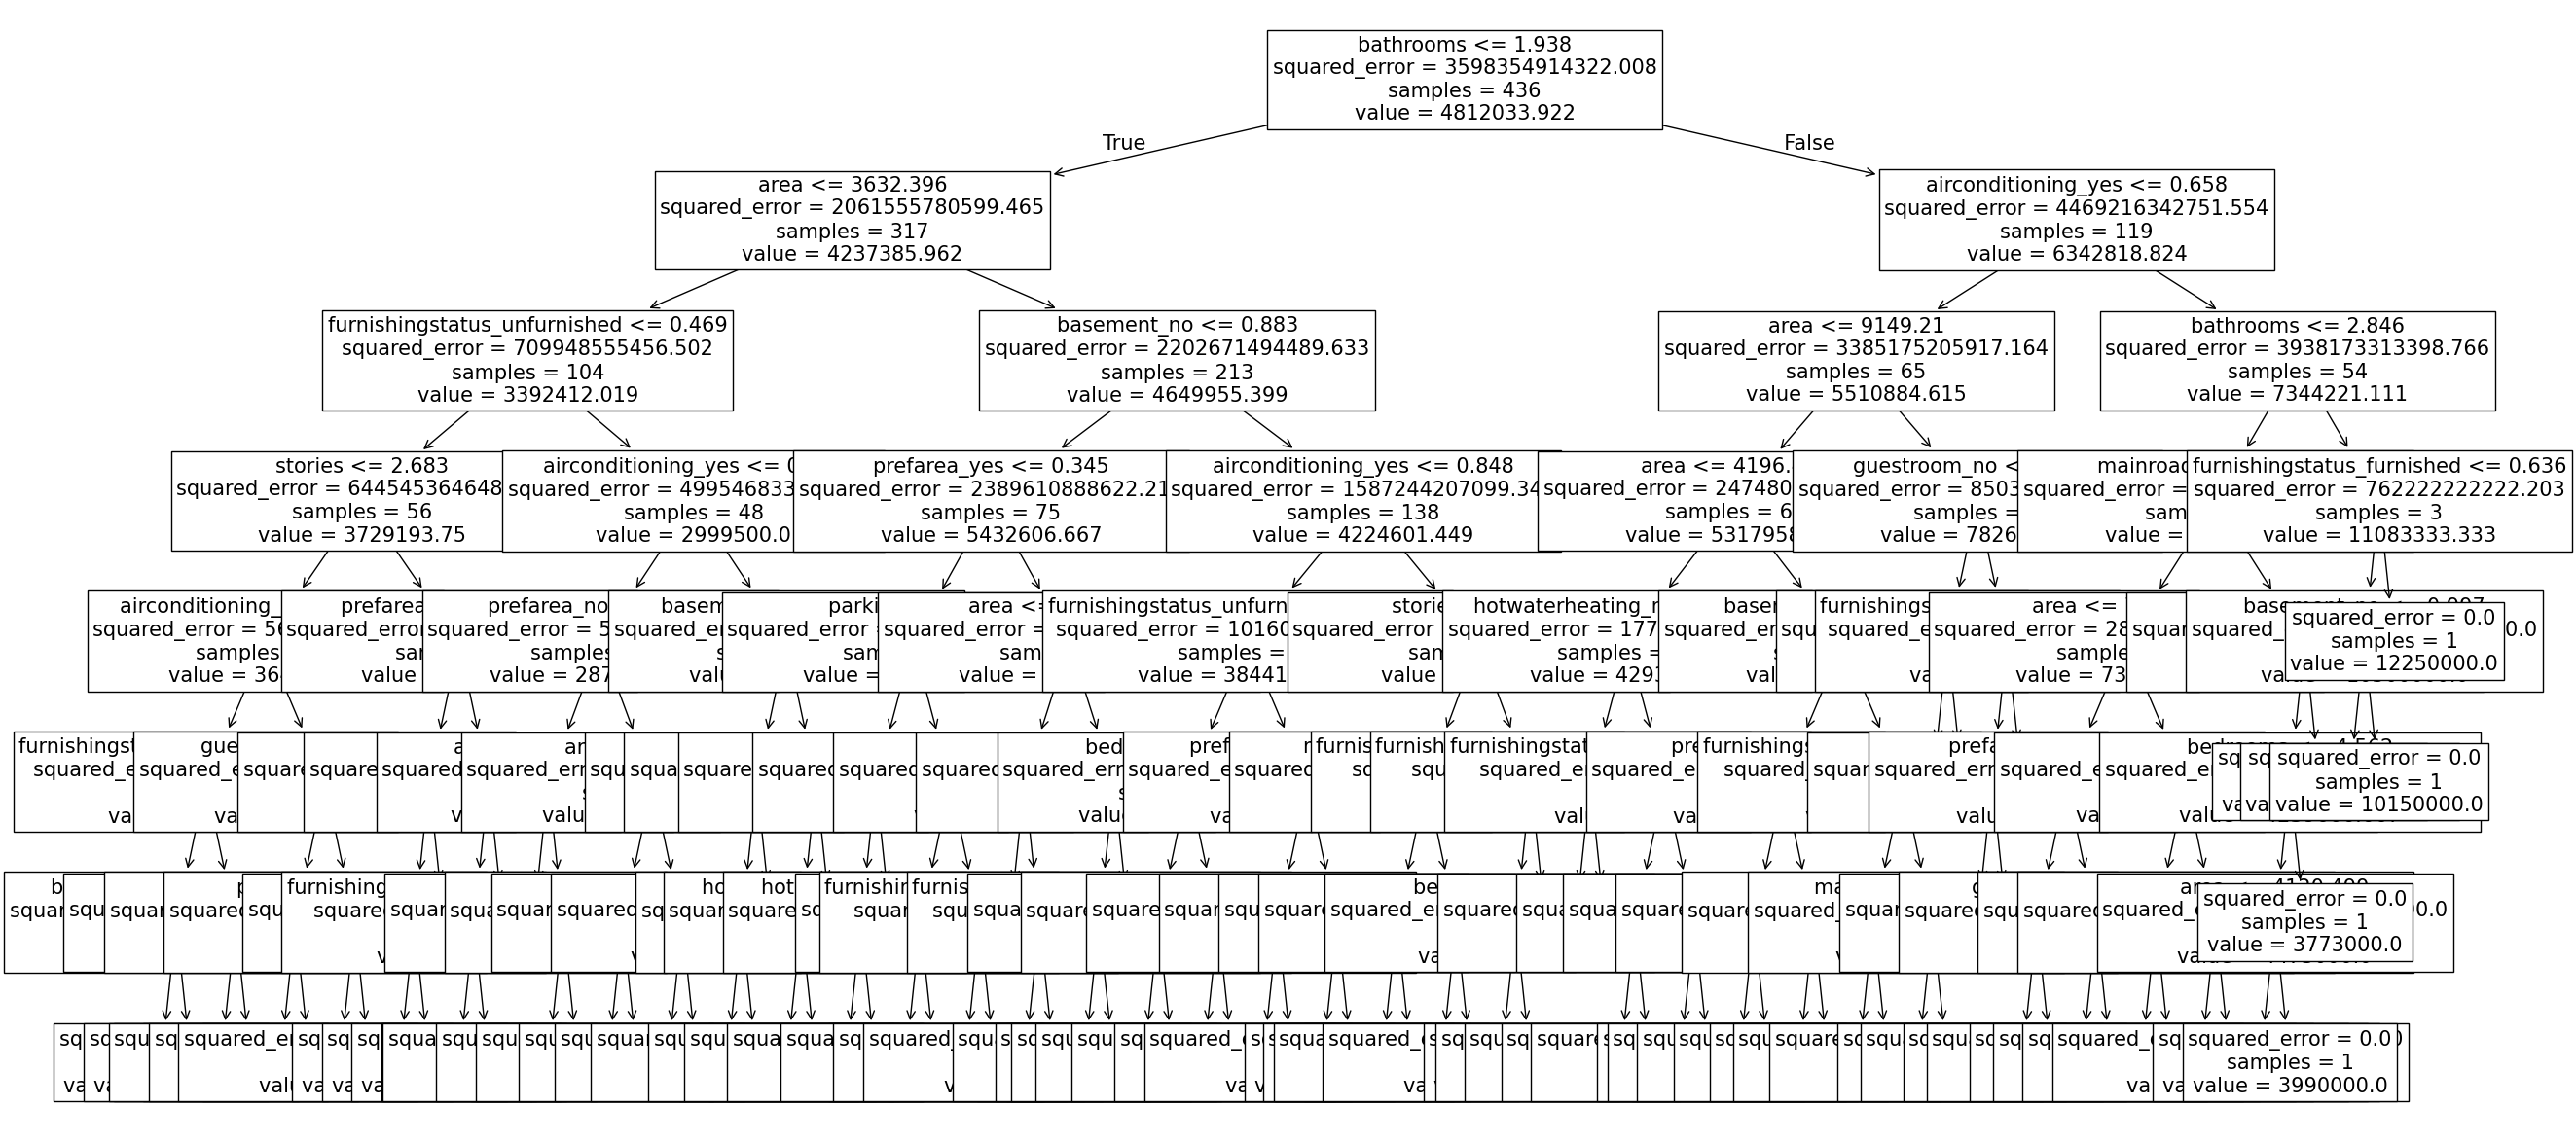

In [30]:
plt.figure(figsize = (30, 15))

plot_tree(tuning_grid.best_estimator_, feature_names=X_features, fontsize=15);
plt.savefig('regressiontree.png')

Important Features - we can get that as well after building gridsearch best params

But -

In [33]:
tuning_grid.best_estimator_.feature_importances_

array([2.01040888e-01, 3.90286589e-02, 3.22612876e-01, 1.93736873e-02,
       3.48911062e-02, 2.81664204e-02, 4.90522366e-03, 2.84664009e-02,
       2.97486732e-04, 5.41230986e-02, 4.92134386e-03, 8.96369449e-03,
       1.61058467e-02, 3.31435892e-03, 1.13634488e-01, 1.51820700e-02,
       4.50393556e-02, 1.17784514e-02, 1.65711525e-02, 3.15833924e-02])

In [34]:
importance_df = pd.DataFrame({'feature': X_features,
                              'importance': tuning_grid.best_estimator_.feature_importances_})

In [35]:
importance_df = importance_df.sort_values('importance', ascending = False)
importance_df

,feature,importance
2,bathrooms,0.322613
0,area,0.201041
14,airconditioning_yes,0.113634
9,basement_no,0.054123
16,prefarea_yes,0.045039
1,bedrooms,0.039029
4,parking,0.034891
19,furnishingstatus_unfurnished,0.031583
7,guestroom_no,0.028466
5,mainroad_no,0.028166
